In [1]:
import numpy as np
import onnxruntime as ort
# from inference.worker_inference import config

d_model = 32
d_state = 32
n_layers = 6
config = {
    "d_model": d_model,
    "n_layers": n_layers,
    "d_state": d_state,
    "d_inner": 2 * d_model,
    "d_conv": 4,
}

x = np.random.randn(1, 8) * 10
hs = np.zeros((5, config["n_layers"], 1, config["d_inner"], config["d_state"]))
inputs = np.zeros((5, config["n_layers"], 1, config["d_inner"], config["d_conv"] - 1))

x = np.float32(x)
hs = np.float32(hs)
inputs = np.float32(inputs)

model_name = "model"
# Define the path to your ONNX model
onnx_model_path = f"{model_name}.onnx"

# Load the ONNX model
ort_session = ort.InferenceSession(onnx_model_path)

In [2]:
# Load some sEMG data from a file
filename = "recording_medium_20_08_2024_12_41_34.csv"

# Load the data
data = np.loadtxt(filename, delimiter=",", skiprows=1)
emg = data[:, :8]  # Skip the timestamp column
finger = data[:, 18:38]
print(emg.shape)

emg = np.abs(emg)  # preprocessing

result = []

# Go token by token and feed it to the model
for i in range(emg.shape[0]):
    x = emg[i, :].reshape(1, 8)
    x = x.astype(np.float32)
    # Run the model
    ort_inputs = {"x": x, "hs.3": hs, "inputs.3": inputs}
    ort_outputs = ort_session.run(None, ort_inputs)
    out = ort_outputs[0]
    hs = ort_outputs[1]
    inputs = ort_outputs[2]
    result.append(out)

result = np.array(result).reshape(-1, 20)

(2016, 8)


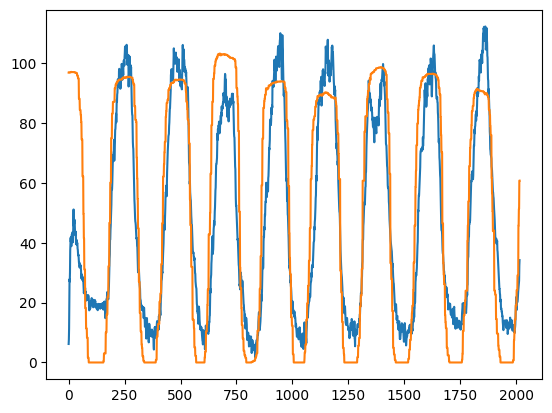

In [3]:
import matplotlib.pyplot as plt

# Plot the result
plt.plot(result[:, 6])
plt.plot(finger[:, 6])

In [ ]:
import time


def measure_fps(onnx_model_path, x_shape, hs_shape, inputs_shape, num_iterations=100):
    # Load the ONNX model
    ort_session = ort.InferenceSession(onnx_model_path)

    # Generate dummy input data (same shape as during export)
    dummy_x = np.random.randn(*x_shape).astype(np.float32)
    dummy_hs = np.random.randn(*hs_shape).astype(np.float32)
    dummy_inputs = np.random.randn(*inputs_shape).astype(np.float32)

    # Warm-up runs (optional but recommended)
    for _ in range(5):
        ort_session.run(None, {"x": dummy_x, "hs.3": dummy_hs, "inputs.3": dummy_inputs})

    # Measure FPS by running multiple iterations
    start_time = time.time()
    for _ in range(num_iterations):
        ort_session.run(None, {"x": dummy_x, "hs.3": dummy_hs, "inputs.3": dummy_inputs})
    end_time = time.time()

    # Calculate FPS
    elapsed_time = end_time - start_time
    fps = num_iterations / elapsed_time
    return fps


# Define the path to your ONNX model
# onnx_model_path = f'trained_models/{model_name}.onnx'
onnx_model_path = f"{model_name}.onnx"

# Define the input shape (matching the dummy input during export)
x_shape = (1, 8)  # Batch size of 1, 8 channels, length of 400
hs_shape = (5, config["n_layers"], 1, config["d_inner"], config["d_state"])
inputs_shape = (5, config["n_layers"], 1, config["d_inner"], config["d_conv"] - 1)

# Run the FPS test
fps = measure_fps(onnx_model_path, x_shape, hs_shape, inputs_shape, num_iterations=1000)
print(f"Model FPS: {fps:.2f} iterations per second")

Model FPS: 275.33 iterations per second
